In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import os
import re
import gc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from transformers import BertTokenizer, BertModel, get_linear_schedule_with_warmup
from torch.optim import AdamW 

# ==========================================
# ⚙️ 設定區
# ==========================================
INPUT_CSV = 'News_Data_cleaned.csv'
MODEL_NAME = 'hfl/chinese-macbert-base' # 使用 MacBERT
MAX_LEN = 256
BATCH_SIZE = 32
EPOCHS = 3
LEARNING_RATE = 2e-5
SEED = 42
CV_FOLDS = 5

if torch.backends.mps.is_available(): DEVICE = torch.device("mps")
elif torch.cuda.is_available(): DEVICE = torch.device("cuda")
else: DEVICE = torch.device("cpu")

def set_seed(seed_value=42):
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed_value)
set_seed(SEED)

In [2]:
# ==========================================
# 1. 資料準備與模型定義
# ==========================================
if not os.path.exists(INPUT_CSV): print("❌ 無檔案"); exit()
df = pd.read_csv(INPUT_CSV)
if 'title_clean' not in df.columns: df['title_clean'] = df['title'].astype(str)
df = df.dropna(subset=['title_clean', 'label'])
df['label'] = df['label'].astype(int)

# 特徵工程函數
def extract_features(df):
    titles = df['title_clean'].astype(str).tolist()
    feats = []
    for t in titles:
        l = len(t)
        p = t.count('!') + t.count('！') + t.count('?') + t.count('？')
        d = 1 if re.search(r'\d', t) else 0
        feats.append([l, p, d])
    return np.array(feats)

# Dataset 與 Model
class HybridDataset(Dataset):
    def __init__(self, texts, extra, labels, tokenizer, max_len):
        self.texts = texts; self.extra = extra; self.labels = labels
        self.tokenizer = tokenizer; self.max_len = max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, item):
        enc = self.tokenizer.encode_plus(str(self.texts[item]), add_special_tokens=True, max_length=self.max_len, padding='max_length', truncation=True, return_tensors='pt')
        return {
            'input_ids': enc['input_ids'].flatten(),
            'attention_mask': enc['attention_mask'].flatten(),
            'extra': torch.tensor(self.extra[item], dtype=torch.float32),
            'labels': torch.tensor(self.labels[item], dtype=torch.long)
        }

class HybridMacBERT(nn.Module):
    def __init__(self, model_name, num_labels=2):
        super().__init__()
        self.bert = BertModel.from_pretrained(model_name)
        self.cls = nn.Sequential(nn.Linear(768+3, 256), nn.ReLU(), nn.Dropout(0.3), nn.Linear(256, num_labels))
    def forward(self, ids, mask, extra):
        out = self.bert(ids, mask).pooler_output
        return self.cls(torch.cat((out, extra), dim=1))

def train_epoch(model, loader, opt, device, sched):
    model.train()
    crit = nn.CrossEntropyLoss() # Oversampling 已處理平衡，故不需 class weight
    for d in loader:
        opt.zero_grad()
        out = model(d['input_ids'].to(device), d['attention_mask'].to(device), d['extra'].to(device))
        loss = crit(out, d['labels'].to(device))
        loss.backward()
        opt.step(); sched.step()

def get_probs(model, loader, device):
    model.eval()
    probs = []
    with torch.no_grad():
        for d in loader:
            out = model(d['input_ids'].to(device), d['attention_mask'].to(device), d['extra'].to(device))
            probs.extend(torch.softmax(out, dim=1)[:, 1].cpu().numpy())
    return np.array(probs)

In [3]:
# ==========================================
# 2. Teacher Step (篩選資料)
# ==========================================
print("🚀 [Phase 1] 訓練 Teacher 模型進行資料淨化...")
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
X_txt = df['title_clean'].values
X_stats = MinMaxScaler().fit_transform(extract_features(df))
y = df['label'].values

# 使用全部資料訓練 Teacher (快速版)
full_ds = HybridDataset(X_txt, X_stats, y, tokenizer, MAX_LEN)
full_loader = DataLoader(full_ds, BATCH_SIZE, shuffle=True)
pred_loader = DataLoader(full_ds, BATCH_SIZE, shuffle=False)

model = HybridMacBERT(MODEL_NAME).to(DEVICE)
opt = AdamW(model.parameters(), lr=LEARNING_RATE)
sch = get_linear_schedule_with_warmup(opt, 0, len(full_loader)*EPOCHS)

for ep in range(EPOCHS):
    train_epoch(model, full_loader, opt, DEVICE, sch)

probs = get_probs(model, pred_loader, DEVICE)
del model; gc.collect(); torch.cuda.empty_cache() if torch.cuda.is_available() else None

# 信心篩選
CONF_TH = 0.8
clean_indices = [i for i, p in enumerate(probs) if p > CONF_TH or p < (1-CONF_TH)]
df_clean = df.iloc[clean_indices].copy()
print(f"   淨化完成: {len(df)} -> {len(df_clean)} 筆 (保留高信心樣本)")

🚀 [Phase 1] 訓練 Teacher 模型進行資料淨化...
   淨化完成: 23527 -> 9582 筆 (保留高信心樣本)


In [4]:
# ==========================================
# 3. Student Step (標準 5-Fold + Oversampling)
# ==========================================
print("\n🚀 [Phase 2] 啟動標準實驗流程 (5-Fold CV + Oversampling)...")

# 準備乾淨資料
X_txt = df_clean['title_clean'].values
X_stats = MinMaxScaler().fit_transform(extract_features(df_clean))
y = df_clean['label'].values

# 1. 切分 80/20
X_txt_tr, X_txt_te, X_stats_tr, X_stats_te, y_tr, y_te = train_test_split(
    X_txt, X_stats, y, test_size=0.2, random_state=SEED, stratify=y
)

# 輔助函數：建立帶有 Oversampling 的 DataLoader
def create_weighted_loader(dataset, labels, batch_size):
    class_counts = np.bincount(labels)
    class_weights = 1. / class_counts
    sample_weights = [class_weights[t] for t in labels]
    sampler = WeightedRandomSampler(sample_weights, len(sample_weights))
    return DataLoader(dataset, batch_size=batch_size, sampler=sampler)

# 2. 5-Fold CV
skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
fold_scores = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_txt_tr, y_tr)):
    print(f"   Running Fold {fold+1}/{CV_FOLDS}...", end="\r")
    
    # 建立 Dataset
    tr_ds = HybridDataset(X_txt_tr[tr_idx], X_stats_tr[tr_idx], y_tr[tr_idx], tokenizer, MAX_LEN)
    val_ds = HybridDataset(X_txt_tr[val_idx], X_stats_tr[val_idx], y_tr[val_idx], tokenizer, MAX_LEN)
    
    # 🔥 關鍵：使用 Weighted Loader
    tr_ld = create_weighted_loader(tr_ds, y_tr[tr_idx], BATCH_SIZE)
    val_ld = DataLoader(val_ds, BATCH_SIZE)
    
    model = HybridMacBERT(MODEL_NAME).to(DEVICE)
    opt = AdamW(model.parameters(), lr=LEARNING_RATE)
    sch = get_linear_schedule_with_warmup(opt, 0, len(tr_ld)*EPOCHS)
    
    for ep in range(EPOCHS):
        train_epoch(model, tr_ld, opt, DEVICE, sch)
        
    probs = get_probs(model, val_ld, DEVICE)
    best_f1 = max([f1_score(y_tr[val_idx], (probs>=th).astype(int)) for th in np.arange(0.3, 0.8, 0.05)])
    fold_scores.append(best_f1)
    del model; torch.mps.empty_cache() if torch.backends.mps.is_available() else None

print(f"\n   ✅ 5-Fold CV 平均 F1: {np.mean(fold_scores):.4f}")

# 3. Final Training
print("\n🚀 [Phase 3] 最終訓練 (Full Train Set)...")
full_tr_ds = HybridDataset(X_txt_tr, X_stats_tr, y_tr, tokenizer, MAX_LEN)
te_ds = HybridDataset(X_txt_te, X_stats_te, y_te, tokenizer, MAX_LEN)

# 🔥 關鍵：Full Train 也使用 Oversampling
tr_ld = create_weighted_loader(full_tr_ds, y_tr, BATCH_SIZE)
te_ld = DataLoader(te_ds, BATCH_SIZE)

model = HybridMacBERT(MODEL_NAME).to(DEVICE)
opt = AdamW(model.parameters(), lr=LEARNING_RATE)
sch = get_linear_schedule_with_warmup(opt, 0, len(tr_ld)*EPOCHS)

for epoch in range(EPOCHS):
    train_epoch(model, tr_ld, opt, DEVICE, sch)
    print(f"   Epoch {epoch+1} done.")


🚀 [Phase 2] 啟動標準實驗流程 (5-Fold CV + Oversampling)...
   Running Fold 5/5...
   ✅ 5-Fold CV 平均 F1: 0.3908

🚀 [Phase 3] 最終訓練 (Full Train Set)...
   Epoch 1 done.
   Epoch 2 done.
   Epoch 3 done.



🔍 [Phase 4] 最終評估...

🏆 【 Self-Training + Oversampling 訓練結果：五大指標成績表 】
Metric          | Score     
------------------------------
Accuracy        | 0.9478
Precision       | 0.4819
Recall          | 0.4124
F1-Score        | 0.4444
AUROC           | 0.7302
------------------------------
5-Fold F1       | 0.3908


📌 模型詳細報告：Self-Training Oversampling (Th=0.70)
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0     0.9689    0.9764    0.9726      1820
           1     0.4819    0.4124    0.4444        97

    accuracy                         0.9478      1917
   macro avg     0.7254    0.6944    0.7085      1917
weighted avg     0.9443    0.9478    0.9459      1917

--------------------------------------------------------------------------------


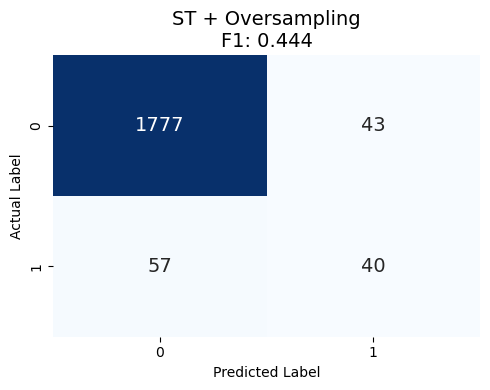

In [5]:
# 4. Final Evaluation
print("\n🔍 [Phase 4] 最終評估...")
probs = get_probs(model, te_ld, DEVICE)
labels = y_te

best_f1, best_th = 0, 0.5
for th in np.arange(0.3, 0.8, 0.01):
    f1 = f1_score(labels, (probs>=th).astype(int))
    if f1 > best_f1: best_f1, best_th = f1, th
y_pred = (probs >= best_th).astype(int)

# 輸出結果
print("\n" + "="*60)
print(f"🏆 【 Self-Training + Oversampling 訓練結果：五大指標成績表 】")
print("="*60)
print(f"{'Metric':<15} | {'Score':<10}")
print("-" * 30)
print(f"{'Accuracy':<15} | {accuracy_score(labels, y_pred):.4f}")
print(f"{'Precision':<15} | {precision_score(labels, y_pred):.4f}")
print(f"{'Recall':<15} | {recall_score(labels, y_pred):.4f}")
print(f"{'F1-Score':<15} | {best_f1:.4f}")
print(f"{'AUROC':<15} | {roc_auc_score(labels, probs):.4f}")
print("-" * 30)
print(f"{'5-Fold F1':<15} | {np.mean(fold_scores):.4f}")
print("\n")

print("="*80)
print(f"📌 模型詳細報告：Self-Training Oversampling (Th={best_th:.2f})")
print("-" * 80)
print(classification_report(labels, y_pred, digits=4))
print("-" * 80)

cm = confusion_matrix(labels, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, annot_kws={"size": 14})
plt.title(f'ST + Oversampling\nF1: {best_f1:.3f}', fontsize=14)
plt.ylabel('Actual Label'); plt.xlabel('Predicted Label')
plt.tight_layout(); plt.show()